# **Conditional Workflow**

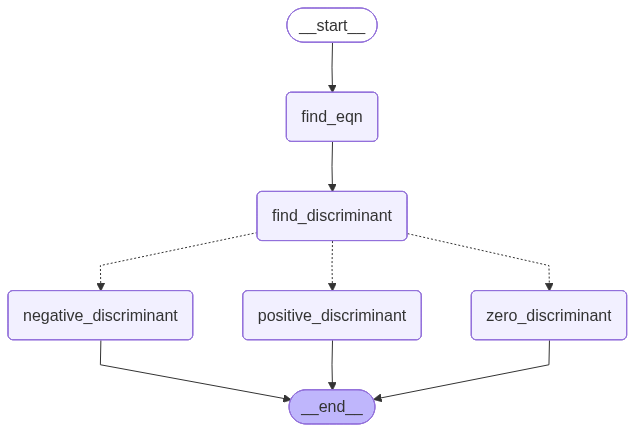

{'a': 1,
 'b': 2,
 'c': 5,
 'eqn': '1X^2 + 2X + 5 = 0',
 'discriminant': -16,
 'wordict': 'The discriminant is negative, so there are no real roots.',
 'x1': None,
 'x2': None}

In [17]:
from dotenv import load_dotenv
load_dotenv()
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from typing import TypedDict,Literal
from IPython.display import Image, display

class Eqn(TypedDict):

    a: int
    b: int
    c: int

    eqn: str
    discriminant: float

    wordict: str
    x1: Literal[float, None]
    x2: Literal[float, None]


def find_eqn(state: Eqn) -> Eqn:
    state['eqn'] = f"{state['a']}X^2 + {state['b']}X + {state['c']} = 0"
    return state

def find_discriminant(state: Eqn) -> Eqn:

    state['discriminant'] = state['b']**2 - 4*state['a']*state['c']
    return state

def positive_discriminant(state: Eqn) -> Eqn:

    state['wordict'] = "The discriminant is positive, so there are two distinct real roots."
    state['x1'] = (-state['b'] + state['discriminant']**0.5) / (2*state['a'])
    state['x2'] = (-state['b'] - state['discriminant'] **0.5) / (2*state['a'])
    return state

def zero_discriminant(state: Eqn) -> Eqn:
    state['wordict'] = "The discriminant is zero, so there is one real root (a repeated root)."
    state['x1'] = (-state['b'] / (2*state['a']))
    state['x2'] = (-state['b'] / (2*state['a']))
    return state

def negative_discriminant(state: Eqn) -> Eqn:
    
    state['wordict'] = "The discriminant is negative, so there are no real roots."
    state['x1'] = None
    state['x2'] = None
    return state


def discriminant_branch(state: Eqn) -> Literal['positive_discriminant', 'zero_discriminant', 'negative_discriminant']:
    if state['discriminant'] > 0:
        return 'positive_discriminant'
    elif state['discriminant'] == 0:
        return 'zero_discriminant'
    
    return 'negative_discriminant'

graph = StateGraph(Eqn)

graph.add_node('find_eqn', find_eqn)
graph.add_node('find_discriminant', find_discriminant)
graph.add_node('positive_discriminant', positive_discriminant)
graph.add_node('zero_discriminant', zero_discriminant)
graph.add_node('negative_discriminant', negative_discriminant)

graph.add_edge(START, 'find_eqn')
graph.add_edge('find_eqn', 'find_discriminant')
graph.add_conditional_edges('find_discriminant', discriminant_branch)
graph.add_edge('positive_discriminant', END)
graph.add_edge('zero_discriminant', END)
graph.add_edge('negative_discriminant', END)

builder = graph.compile()
display(Image(builder.get_graph(xray=True).draw_mermaid_png()))

payload = {
    "a": 1,
    "b": 2,
    "c": 5
}

builder.invoke(payload)